In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as p
import seaborn as sns

In [2]:
df=pd.read_csv("insurance.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
1117,25,male,33.330,2,yes,southeast,36124.57370
565,19,female,30.495,0,no,northwest,2128.43105
926,19,female,23.400,2,no,southwest,2913.56900
639,56,male,33.660,4,no,southeast,12949.15540
1280,48,female,33.330,0,no,southeast,8283.68070


In [6]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df[df.duplicated]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [9]:
df.drop_duplicates(keep="first")

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [10]:
numeric_corr = df.corr(numeric_only=True)
print(numeric_corr)

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


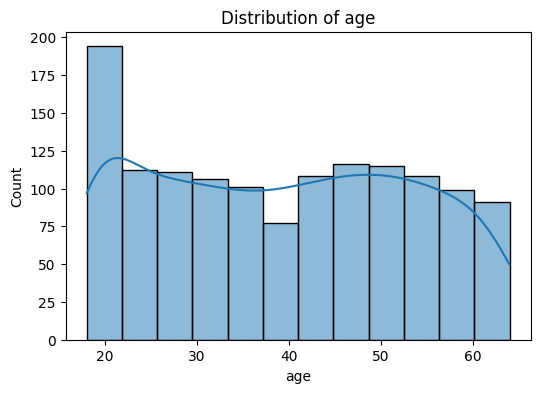

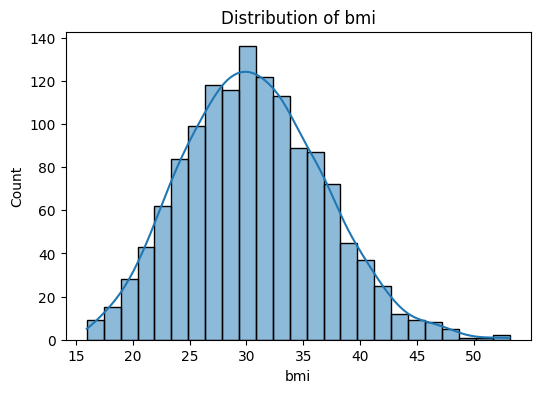

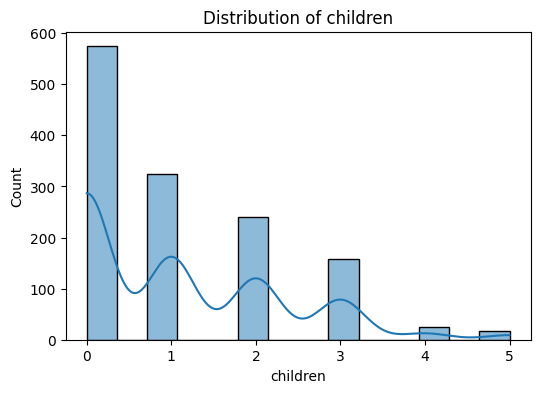

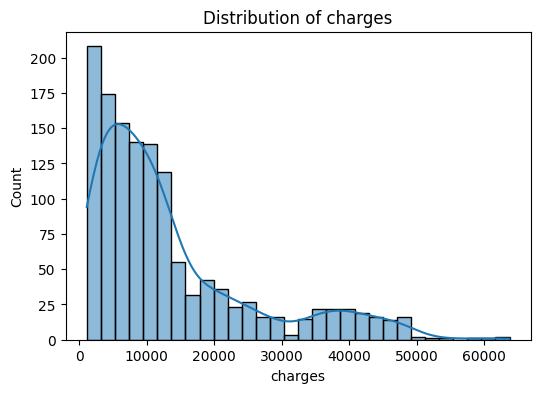

In [11]:
numerical_cols = ['age','bmi','children','charges']

for col in numerical_cols:
    p.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    p.title(f'Distribution of {col}')
    p.show()

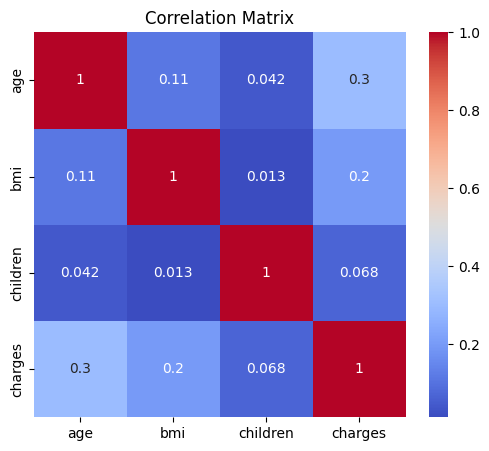

In [12]:
p.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
p.title("Correlation Matrix")
p.show()

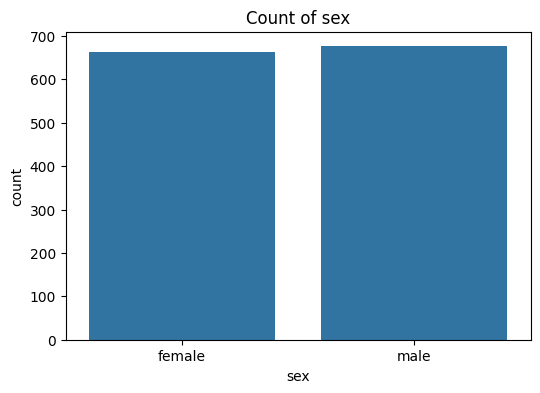

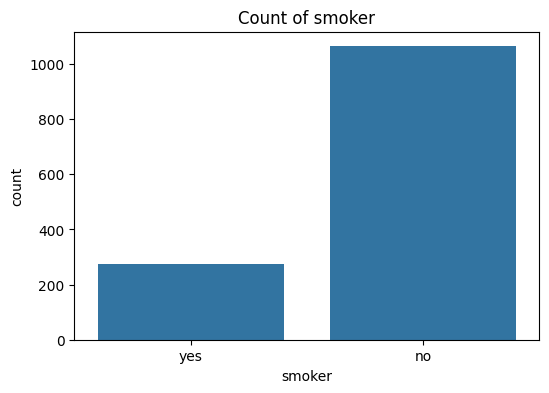

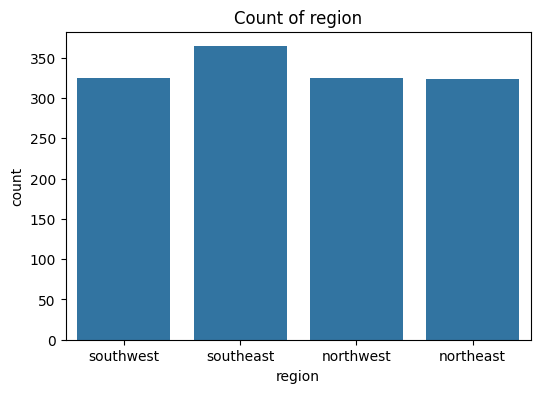

In [13]:
categorical_cols = ['sex','smoker','region']

for col in categorical_cols:
    p.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    p.title(f'Count of {col}')
    p.show()

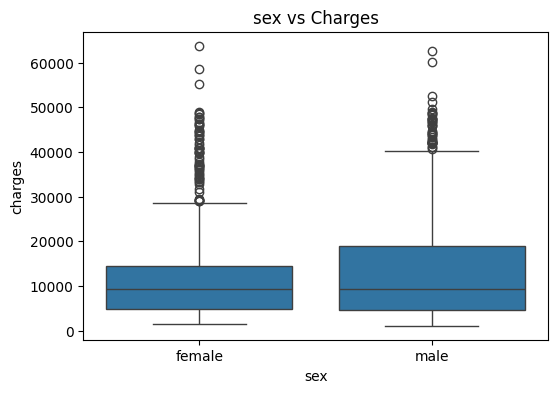

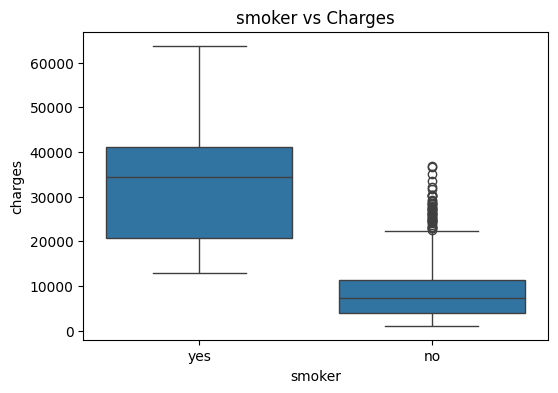

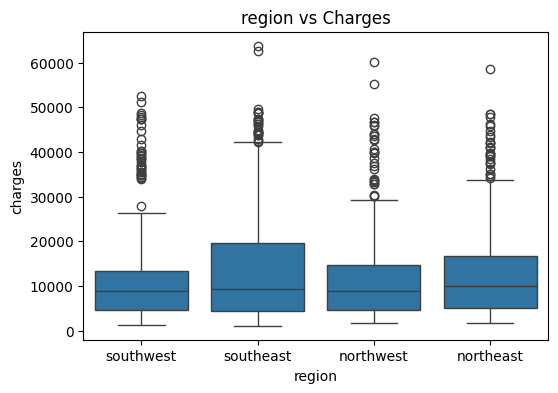

In [14]:
for col in categorical_cols:
    p.figure(figsize=(6,4))
    sns.boxplot(x=col, y='charges', data=df)
    p.title(f'{col} vs Charges')
    p.show()

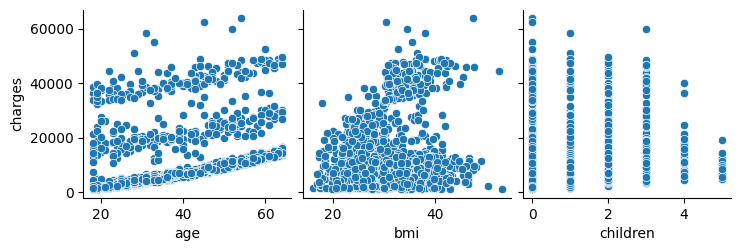

In [15]:
sns.pairplot(df, x_vars=['age','bmi','children'], y_vars='charges', kind='scatter')
p.show()

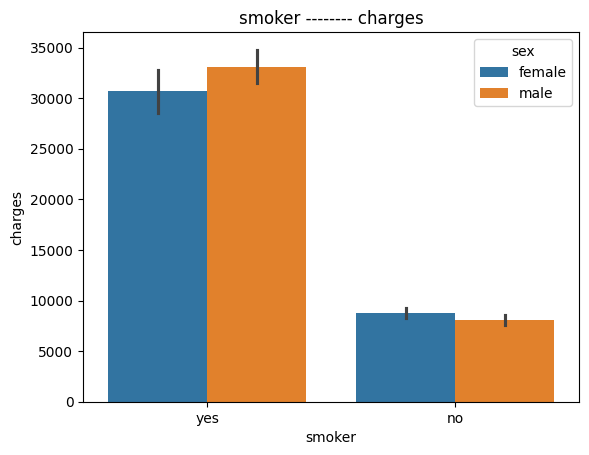

In [16]:
sns.barplot(x='smoker', y='charges', hue='sex', data=df)

p.xlabel("smoker")
p.ylabel("charges")
p.title("smoker -------- charges")
p.show()

In [17]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [18]:
df["sex"].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [19]:
df["region"].unique()


<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [20]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

In [21]:
oe=OrdinalEncoder(categories=[["female","male"],["yes","no"]])

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df.iloc[:,0:6],
    df.iloc[:,-1],
    test_size=0.3,
    random_state=42
)

In [23]:
from sklearn.compose import ColumnTransformer
transformer = ColumnTransformer(
    transformers=[
        ('ordinal_encoding', 
         OrdinalEncoder(categories=[['female','male'], ['yes','no']]), 
         ['sex','smoker']),
        ('onehot_encoding', 
         OneHotEncoder(sparse_output=False, drop='first'), 
         ['region'])
    ],
    remainder='passthrough' 
)


In [24]:
x_train_n=transformer.fit_transform(X_train)

In [25]:
x_test_n=transformer.transform(X_test)

In [26]:
feature_names = transformer.get_feature_names_out()
print(feature_names)

['ordinal_encoding__sex' 'ordinal_encoding__smoker'
 'onehot_encoding__region_northwest' 'onehot_encoding__region_southeast'
 'onehot_encoding__region_southwest' 'remainder__age' 'remainder__bmi'
 'remainder__children']


In [27]:
df_train=pd.DataFrame(x_train_n,columns=feature_names)
df_test=pd.DataFrame(x_test_n,columns=feature_names)


In [28]:
from sklearn.linear_model import LinearRegression


In [29]:
df_train

    

,ordinal_encoding__sex,ordinal_encoding__smoker,onehot_encoding__region_northwest,onehot_encoding__region_southeast,onehot_encoding__region_southwest,remainder__age,remainder__bmi,remainder__children
0,0.0,1.0,1.0,0.0,0.0,61.0,31.160,0.0
1,1.0,1.0,0.0,0.0,1.0,46.0,27.600,0.0
2,0.0,1.0,0.0,1.0,0.0,54.0,31.900,3.0
3,1.0,0.0,0.0,0.0,0.0,55.0,30.685,0.0
4,1.0,0.0,0.0,1.0,0.0,25.0,45.540,2.0
...,...,...,...,...,...,...,...,...
931,0.0,1.0,0.0,0.0,0.0,18.0,31.350,4.0
932,0.0,1.0,0.0,1.0,0.0,39.0,23.870,5.0
933,1.0,1.0,0.0,0.0,0.0,58.0,25.175,0.0
934,0.0,0.0,0.0,0.0,1.0,37.0,47.600,2.0


In [30]:
model=LinearRegression()
model.fit(df_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
y_predi=model.predict(df_test)

In [32]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2 = r2_score(y_test, y_predi)
mse = mean_squared_error(y_test, y_predi)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_predi)

print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")


R² Score: 0.7696
Mean Squared Error (MSE): 33780509.5748
Root Mean Squared Error (RMSE): 5812.1003
Mean Absolute Error (MAE): 4145.4506


In [33]:
print(f"Intercept: {model.intercept_}")

Intercept: 11254.403319324521


In [34]:
print("Slopes (Coefficients):")

for feature, coef in zip(df_train.columns, model.coef_):
    print(f"{feature}: {coef}")

Slopes (Coefficients):
ordinal_encoding__sex: 104.81182298826465
ordinal_encoding__smoker: -23628.367222359968
onehot_encoding__region_northwest: -486.9346104729675
onehot_encoding__region_southeast: -970.9688385666166
onehot_encoding__region_southwest: -926.3229079115681
remainder__age: 261.29692414191595
remainder__bmi: 348.9069151601793
remainder__children: 424.11912829169387


Text(0.5, 1.0, 'Actual vs Predicted Charges')

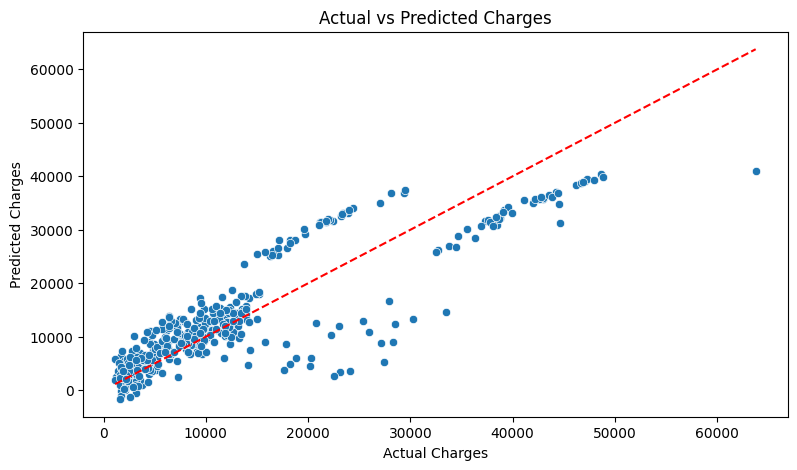

In [35]:
p.figure(figsize=(20,5))
p.subplot(1,2,1)
sns.scatterplot(x=y_test, y=y_predi)
p.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Perfect prediction line
p.xlabel("Actual Charges")
p.ylabel("Predicted Charges")
p.title("Actual vs Predicted Charges")


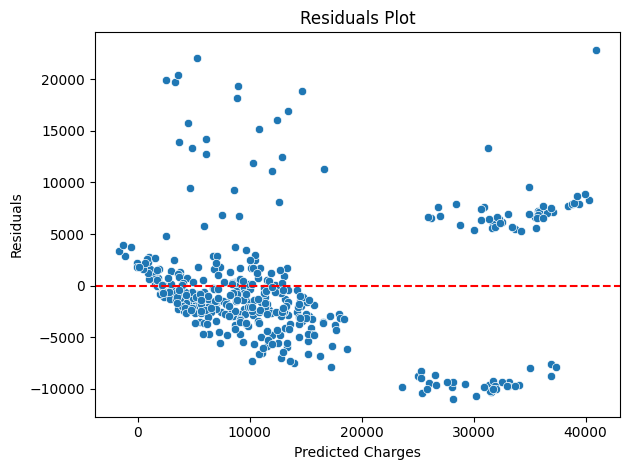

In [36]:
p.subplot(1,1,1)
residuals= y_test - y_predi
sns.scatterplot(x=y_predi, y=residuals)
p.axhline(0, color='red', linestyle='--')
p.xlabel("Predicted Charges")
p.ylabel("Residuals")
p.title("Residuals Plot")

p.tight_layout()
p.show()